# ChaosQKT with Psyduck: Quantum Chaos Simulation Tutorial

**Tutorial for Quantum Chaos Simulations using the Psyduck Framework**

This notebook demonstrates quantum chaos dynamics simulations using the **psyduck** library.

The notebook uses ONLY:
- `psyduck` module (core framework)
- `psyduck.plotting` subfolder (Wigner visualization)

# Section 1: Setup and import psyduck (and other stuff)



In [16]:
%matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import importlib

# Add the project root to Python path (2 levels up from examples/chaosqkt/)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0, project_root)

# Force reload of psyduck modules
for module_name in list(sys.modules.keys()):
    if module_name.startswith('psyduck'):
        del sys.modules[module_name]

# Import psyduck library fresh
from psyduck import Spin
from psyduck.plotting import *
from psyduck.evolve import kicked_dynamics, otoc_trajectory
from psyduck.operations import global_rotation
from psyduck.hamiltonians import Hz_order

print("✓ Psyduck loaded successfully!")
print(f"QuTiP version: {qt.__version__}")


✓ Psyduck loaded successfully!
QuTiP version: 5.0.2


# Section 2: Create a Spin object using psyduck.

In [17]:
# Define spin quantum number
I = 7/2  # Spin-7/2 system (dimension 8)

# Create a Spin object using psyduck
nucleus = Spin(I=I)

print(f"✓ Created Spin system: I = {I},   Hilbert space dimension: {nucleus.dim}")

# Get spin operators
Ix, Iy, Iz = nucleus.get_spin_operators()
print(f"✓ Spin operators created (shape: {Ix.shape})")

✓ Created Spin system: I = 3.5,   Hilbert space dimension: 8
✓ Spin operators created (shape: (8, 8))


In [18]:
Ix

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.         1.32287566 0.         0.         0.         0.
  0.         0.        ]
 [1.32287566 0.         1.73205081 0.         0.         0.
  0.         0.        ]
 [0.         1.73205081 0.         1.93649167 0.         0.
  0.         0.        ]
 [0.         0.         1.93649167 0.         2.         0.
  0.         0.        ]
 [0.         0.         0.         2.         0.         1.93649167
  0.         0.        ]
 [0.         0.         0.         0.         1.93649167 0.
  1.73205081 0.        ]
 [0.         0.         0.         0.         0.         1.73205081
  0.         1.32287566]
 [0.         0.         0.         0.         0.         0.
  1.32287566 0.        ]]

# Section 3: Create Initial Spin-Coherent State

In [19]:
# Create a spin-coherent state at specific polar angles
theta = 0.0 * np.pi  # Polar angle (0 to π)
phi = 0.0 * np.pi   # Azimuthal angle (0 to 2π)

# Use the spin.py method to create the displaced coherent state
nucleus.make_displaced_coherent_state(theta=theta, phi=phi)
psi_initial = nucleus.state

print(f"✓ Created initial state at θ={theta:.3f}, φ={phi:.3f}")

✓ Created initial state at θ=0.000, φ=0.000


## 3.1a Visualize the Prepared State

Plot the Wigner (and Husimi Q) function of the prepared spin-coherent state using the projections available in `psyduck.plotting`:

- `wigner_plot_hammer` - Hammer equal-area projection
- `wigner_plot_3d` - 3D sphere
- `wigner_plot_polar` - polar (azimuthal-equidistant) projection
- `projection_plot_spin_wigner` - 3D sphere with three side projections
- `wigner_plot` - 3D + Hammer side-by-side

Each wrapper also accepts `prob_function='husimi'` to plot the Husimi Q distribution instead of the Wigner function.

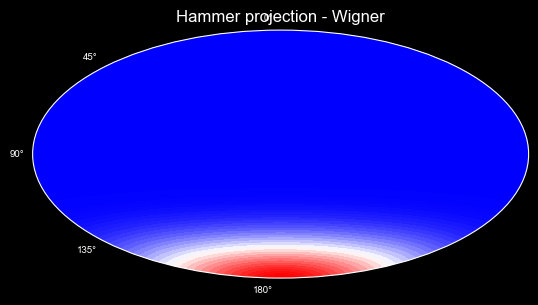

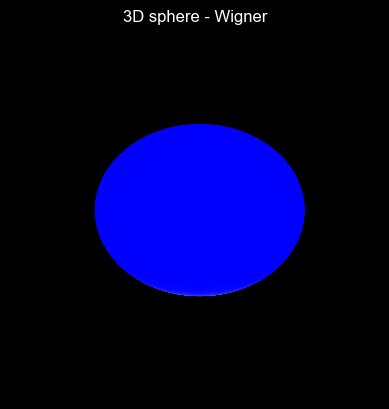

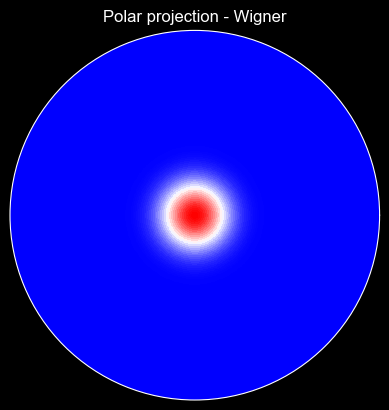

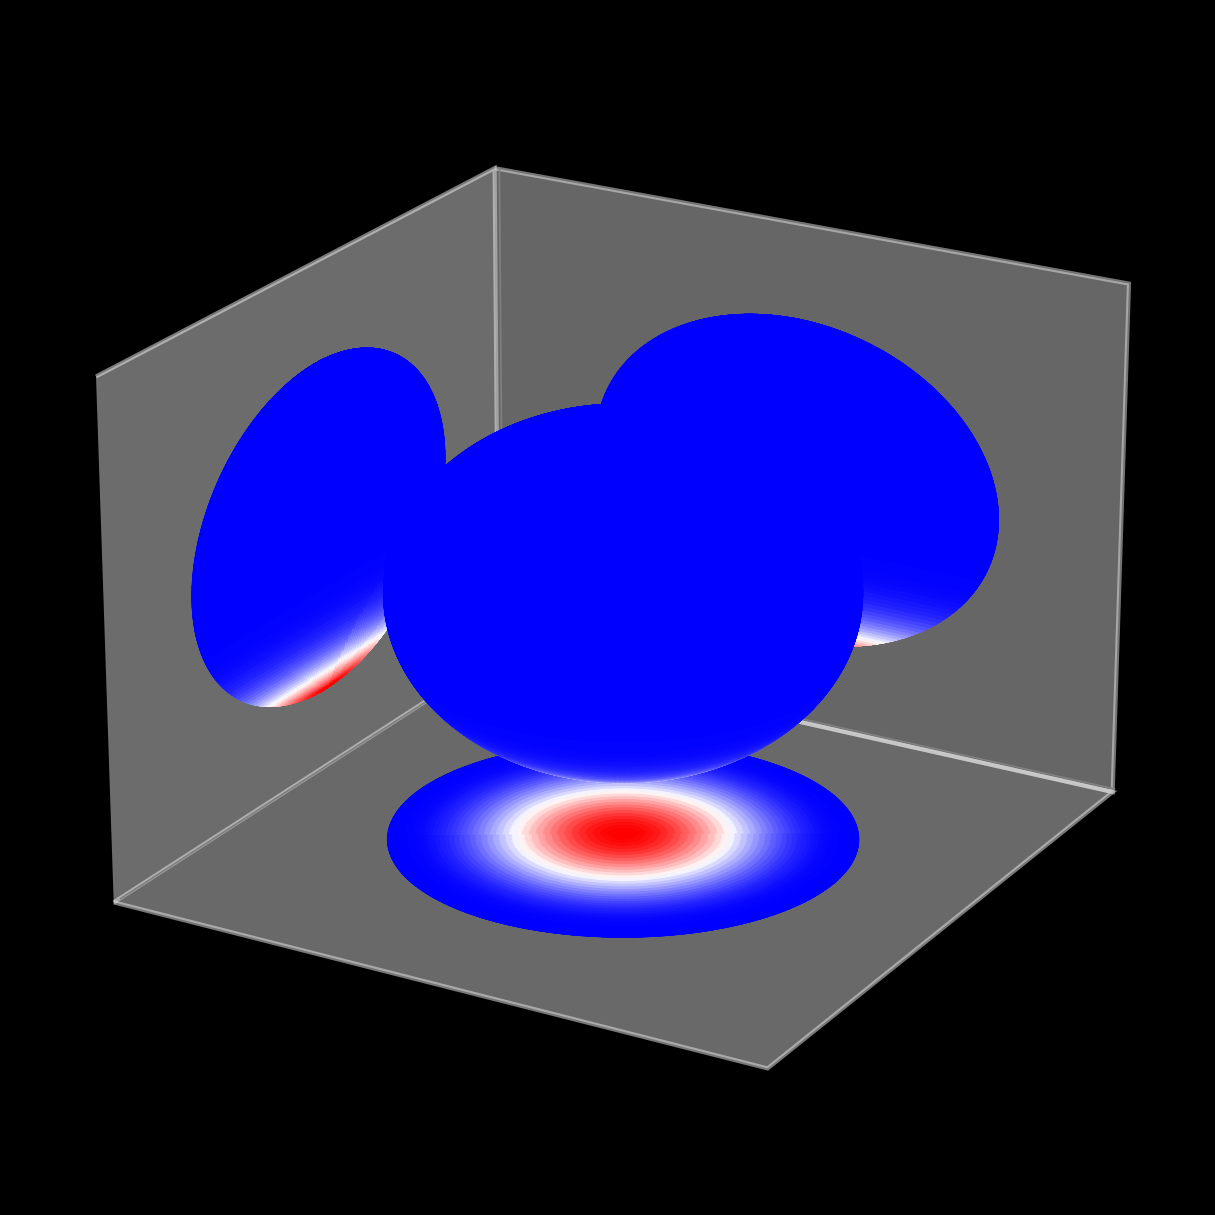

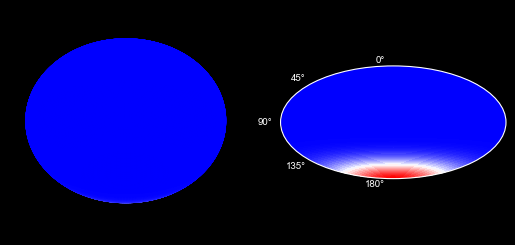

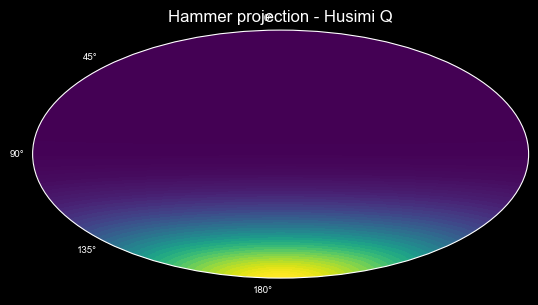

✓ Initial state visualized across multiple projections
  The sharp peak indicates a well-defined spin-coherent state


In [20]:
# 1. Hammer equal-area projection (Wigner)
fig, ax, _ = wigner_plot_hammer(psi_initial,n_theta=101,n_phi=201,cmap='bwr')
ax.set_title('Hammer projection - Wigner')
plt.show()

# 2. 3D sphere (Wigner)
fig, ax, _ = wigner_plot_3d(    psi_initial,n_theta=101,n_phi=201,cmap='bwr')
ax.set_title('3D sphere - Wigner')
plt.show()

# 3. Polar (azimuthal-equidistant) projection (Wigner)
fig, ax = wigner_plot_polar(psi_initial,n_theta=101,n_phi=201,cmap='bwr')
ax.set_title('Polar projection - Wigner')
plt.show()

# 4. 3D sphere with three side projections (Wigner)
fig, ax, _, _, _ = projection_plot_spin_wigner(psi_initial,n_theta=101,n_phi=201,cmap='bwr',figsize=(6, 5))
plt.show()

# 5. 3D + Hammer side-by-side via wigner_plot
wigner_plot(psi_initial)
plt.show()

# 6. Husimi Q distribution on a Hammer projection (compare with Wigner above)
fig, ax, _ = wigner_plot_hammer(psi_initial,n_theta=101,n_phi=201,cmap='viridis',prob_function='husimi')
ax.set_title('Hammer projection - Husimi Q')
plt.show()

print("✓ Initial state visualized across multiple projections")
print("  The sharp peak indicates a well-defined spin-coherent state")

### 3.1b Stereographic projection

Stereographic projection maps the sphere onto a plane by drawing a ray from one pole through every other point on the sphere to the equatorial plane.  It is **conformal** (angle-preserving) but not area-preserving: regions near the projection pole are stretched outward toward infinity.

With the projection point at the south pole (theta = pi), the planar radius is

$$r = 	an(	heta / 2), \qquad x = r \cos\phi, \qquad y = r \sin\phi.$$

So the north pole (theta = 0) lands at the origin and the south pole would map to infinity.  `wigner_plot_stereographic` masks points beyond a configurable `r_max` to keep the plot bounded, and `pole='north'` swaps the convention so the south pole sits at the centre instead.

C:\Users\z5459034\Documents\Gits\Psyduck\psyduck\plotting\wigner_plot.py:324: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x, y, plot_data, cmap=cmap, vmin=vmin, vmax=vmax, **kwargs)


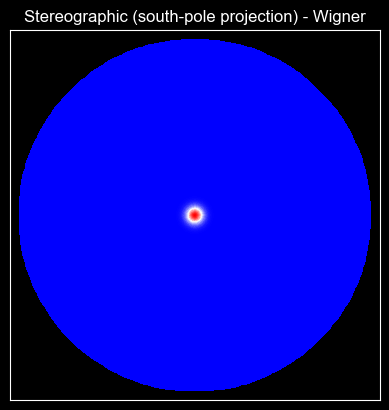

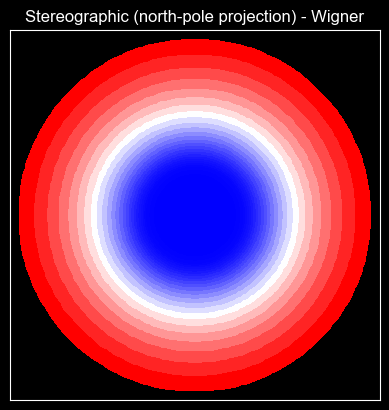

✓ Stereographic projection complete - compare angular sharpness with Hammer / polar above


In [21]:
# Stereographic projection (south-pole convention): north pole at centre
fig, ax, _ = wigner_plot_stereographic(
    psi_initial,
    n_theta=101,
    n_phi=201,
    cmap='bwr',
    pole='south'
)
ax.set_title('Stereographic (south-pole projection) - Wigner')
plt.show()

# Stereographic projection (north-pole convention): south pole at centre
fig, ax, _ = wigner_plot_stereographic(
    psi_initial,
    n_theta=101,
    n_phi=201,
    cmap='bwr',
    pole='north'
)
ax.set_title('Stereographic (north-pole projection) - Wigner')
plt.show()

print("✓ Stereographic projection complete - compare angular sharpness with Hammer / polar above")

## 3.2 Expectation Values and Linear Entropy of the nucleus

In [22]:
# Calculate expectation values using Spin.expectation() method
exp_Ix = nucleus.expectation(Ix)
exp_Iy = nucleus.expectation(Iy)
exp_Iz = nucleus.expectation(Iz)
print(f"\nExpectation values using nucleus.expectation():")
print(f"  <Jx> = {exp_Ix:.4f}")
print(f"  <Jy> = {exp_Iy:.4f}")
print(f"  <Jz> = {exp_Iz:.4f}")

# Calculate linear entropy using nucleus.linear_entropy() method
entropy = nucleus.linear_entropy()
print(f"\nLinear entropy (using nucleus.linear_entropy):\n {entropy:.6f}")


Expectation values using nucleus.expectation():
  <Jx> = 0.0000
  <Jy> = 0.0000
  <Jz> = 3.5000

Linear entropy (using nucleus.linear_entropy):
 0.000000


# Section 4: Run Kicked Dynamics Simulation

Simulate the quantum kicked top with nonlinear pulses, then visualize the evolution with an interactive slider showing Wigner functions in Hammer projection after each kick. The Hamiltonian of the kicked top has the form,
$$
H(t) = \frac{\pi}{2\tau} I_y + \frac{\kappa}{2j} I_z^2
$$
equation (2) from
Neill, C. et al. "Ergodic dynamics and thermalization in an isolated quantum system." Nature Phys 12, 1037–1041 (2016).


Note here, in `kicked_dynamics(psi_initial, tau, kappa, I, N, order, pulse_type)`, the `order` argument sets the power of the nonlinear kick operator, `U_pulse = exp[-i * kappa * I_z**order / (order * I**(order - 1))]`.
The `order` parameter controls the nonlinearity:
- **Order 2** (quadratic): $I_z^2$ -> weaker, smoother
- **Order 3** (cubic): $I_z^3$ -> stronger, more chaotic
- **Higher orders**: More complex classical dynamics


In [ ]:
# Simulation parameters
tau = 1.0      # Free evolution time between kicks
kappa = 3.5 * np.pi    # Kick strength (nonlinearity parameter)
N_kicks = 20   # Number of kicks
order = 2      # Nonlinear kick order

print("Running kicked dynamics simulation...")
print(f"Parameters: tau={tau}, kappa={kappa}, N={N_kicks}, order={order}")

# Use kicked_dynamics from psyduck.evolve
psi_list, overlap_list, entropy_list, exp_list = kicked_dynamics(
    psi_initial, tau, kappa, I, N=N_kicks, order=order, pulse_type='pulse'
)

print(f"✓ Simulation completed!")
print(f"  Generated {len(psi_list)} states")
print(f"\nChaos Metrics:")
print(f"  Initial entropy: {entropy_list[0]:.6f}")
print(f"  Final entropy: {entropy_list[-1]:.6f}")
print(f"  Entropy increase: {entropy_list[-1] - entropy_list[0]:.6f}")
print(f"  Final overlap: |<ψ(0)|ψ(T)>| = {abs(overlap_list[-1]):.6f}")

### 4.1 Interactive Wigner Function Visualization with Slider

Use the slider below to explore the Wigner function after each kick. The Hammer projection shows the phase space evolution throughout the simulation.

In [ ]:
from psyduck.plotting.wigner_plot import plot_wigner_evolution_frame
from ipywidgets import interact, IntSlider, fixed
%matplotlib inline
# Create interactive slider widget
print("\n" + "="*70)
print("Interactive Wigner Function Visualization")
print("="*70)
print(f"Slide to browse through all {len(psi_list)} states")
print(f"Observe phase space evolution from kick 0 to {N_kicks}")
print("="*70 + "\n")

interact(
    plot_wigner_evolution_frame,
    kick_number=IntSlider(
        min=0,
        max=N_kicks,
        step=1,
        value=0,
        description="Kick:",
        continuous_update=True,
        layout={"width": "500px"}
    ),
    psi_list=fixed(psi_list),
    entropy_list=fixed(entropy_list),
    overlap_list=fixed(overlap_list)
)


### Section 4.2: Plot Evolution Metrics

Visualize the system dynamics across all kicks from the Section 4 simulation.

In [ ]:
# Plot 1: Overlap evolution
fig_overlap, ax_overlap = plt.subplots(figsize=(8, 5))
ax_overlap.plot(range(len(overlap_list)), abs(np.array(overlap_list)), 'o-', 
                linewidth=2, markersize=6, color='C0')
ax_overlap.set_xlabel('Kick Number', fontsize=12)
ax_overlap.set_ylabel('|Overlap|', fontsize=12)
ax_overlap.set_title('State Overlap Evolution', fontsize=12, fontweight='bold')
ax_overlap.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 2: Entropy evolution
fig_entropy, ax_entropy = plt.subplots(figsize=(8, 5))
ax_entropy.plot(range(len(entropy_list)), entropy_list, 'o-', 
                color='red', linewidth=2, markersize=6)
ax_entropy.set_xlabel('Kick Number', fontsize=12)
ax_entropy.set_ylabel('Entropy', fontsize=12)
ax_entropy.set_title('Entropy Evolution (Chaos Indicator)', fontsize=12, fontweight='bold')
ax_entropy.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 3: Expectation values evolution
exp_array = np.array(exp_list)
kicks = np.arange(len(exp_list))
fig_exp, ax_exp = plt.subplots(figsize=(8, 5))
ax_exp.plot(kicks, exp_array[:, 0], 'o-', label='<Jx>', linewidth=2, markersize=4)
ax_exp.plot(kicks, exp_array[:, 1], 's-', label='<Jy>', linewidth=2, markersize=4)
ax_exp.plot(kicks, exp_array[:, 2], '^-', label='<Jz>', linewidth=2, markersize=4)
ax_exp.set_xlabel('Kick Number', fontsize=12)
ax_exp.set_ylabel('Expectation Value', fontsize=12)
ax_exp.set_title('Angular Momentum Evolution', fontsize=12, fontweight='bold')
ax_exp.legend(fontsize=10)
ax_exp.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5: Compare Kicked Dynamics Across Different Spin Numbers

Run kicked dynamics with tunable spin number I (while keeping all other parameters fixed from Section 4), then compare the state overlap evolution across different spin systems.


In [ ]:
# Section 5: Setup parameters (tunable spin number, fixed other parameters)
# Use the same parameters from Section 4, but allow varying spin number I

# ===== TUNABLE PARAMETERS =====
spin_numbers = [3.5]  # Change (add) this list to compare different spin systems
# ==============================

# Fixed parameters (from Section 4)
tau = 1.0      # Free evolution time between kicks
kappa = 3.5 * np.pi    # Kick strength (nonlinearity parameter)
N_kicks = 20   # Number of kicks
order = 2      # Nonlinear kick order

print("="*70)
print("Section 5: Comparing Overlap Evolution Across Spin Numbers")
print("="*70)
print(f"Fixed parameters: τ={tau}, κ={kappa}, N={N_kicks}, order={order}")
print(f"Varying spin numbers: {spin_numbers}")

# Dictionary to store results for each spin number
overlap_data = {}
entropy_data = {}

# Run kicked dynamics for each spin number
for spin_I in spin_numbers:
    # Create a Spin object
    nucleus_compare = Spin(I=spin_I)
    nucleus_compare.make_displaced_coherent_state(theta=0, phi=0)
    psi_initial_compare = nucleus_compare.state
    
    # Run kicked dynamics
    psi_list, overlap_list, entropy_list, exp_list = kicked_dynamics(
        psi_initial_compare, tau, kappa, spin_I, N=N_kicks, order=order, pulse_type='pulse'
    )
    
    # Store results
    overlap_data[spin_I] = overlap_list
    entropy_data[spin_I] = entropy_list
 


In [ ]:
# Section 5: Plot overlap evolution comparison across spin numbers

fig_overlap_compare, ax_overlap_compare = plt.subplots(figsize=(10, 6))

for spin_I in spin_numbers:
    ax_overlap_compare.plot(
        range(len(overlap_data[spin_I])), 
        abs(np.array(overlap_data[spin_I])), 
        'o-', linewidth=2, markersize=6, label=f'I = {spin_I}'
    )

ax_overlap_compare.set_xlabel('Kick Number', fontsize=12)
ax_overlap_compare.set_ylabel('|Overlap|', fontsize=12)
ax_overlap_compare.set_title('State Overlap Evolution: Comparison Across Spin Numbers', 
                              fontsize=12, fontweight='bold')
ax_overlap_compare.legend(fontsize=10)
ax_overlap_compare.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 6: Compare Initial and Final States

Visualize the phase space evolution using different Wigner function projections from psyduck.plotting.

### Section 6.1: Hammer Projection

Visualize the phase space using Hammer projection from psyduck.plotting.

In [ ]:
# Compare initial and final states using wigner_plot_hammer
# Initial state
fig_init, ax_init, _ = wigner_plot_hammer(psi_list[0], n_theta=101, n_phi=201, cmap='bwr')
ax_init.set_title('Initial State (Kick 0)', fontsize=12, fontweight='bold')
plt.show()

# Final state
fig_final, ax_final, _ = wigner_plot_hammer(psi_list[-1], n_theta=101, n_phi=201, cmap='bwr')
ax_final.set_title(f'Final State (Kick {len(psi_list)-1})', fontsize=12, fontweight='bold')
plt.show()

print("✓ Initial and final states compared")
print(f"  Initial: Sharp peak indicating pure spin-coherent state")
print(f"  Final: Spread distribution indicating decoherence/chaos")

## Section 7: Dynamical Tunneling Analysis

Analyze tunneling dynamics by computing overlap (fidelity) with the initial state and identifying tunneling frequencies via FFT.

In [ ]:
# Single spin system tunneling analysis
spin = 3.5

# Create a new Spin object for tunneling analysis
tunnel_nucleus = Spin(I=spin)
tunnel_nucleus.make_displaced_coherent_state(theta=2.25, phi=0.7)
psi_tunnel_initial = tunnel_nucleus.state

# Run kicked dynamics for tunneling analysis
tau = 1.0
kappa = 3.0
n_kicks = 500

psi_tunnel_list, _, _, _ = kicked_dynamics(
    psi_tunnel_initial, tau, kappa, spin, N=n_kicks, order=2, pulse_type='pulse'
)

# Calculate overlap (fidelity) with initial state
overlap = np.zeros(len(psi_tunnel_list))
for i in range(len(psi_tunnel_list)):
    overlap[i] = qt.fidelity(psi_tunnel_list[0], psi_tunnel_list[i])

# Compute FFT
fft_vals = np.fft.fft(overlap)
fft_freqs = np.fft.fftfreq(len(overlap))

# Remove DC component
fft_vals_no_dc = fft_vals[1:len(fft_vals)//2]
fft_freqs_no_dc = fft_freqs[1:len(fft_vals)//2]
fft_mag = np.abs(fft_vals_no_dc)

# Plot overlap and FFT
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Fidelity over time
axes[0].plot(np.arange(len(overlap)), overlap, linewidth=2, color='C0')
axes[0].set_xlabel('Kick Number', fontsize=12)
axes[0].set_ylabel('Fidelity with Initial State', fontsize=12)
axes[0].set_title(f'Overlap vs Time (spin = {spin})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right: FFT magnitude spectrum
axes[1].plot(fft_freqs_no_dc, fft_mag, linewidth=1.5, color='red')
axes[1].set_xlim(0, 0.15)
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].set_ylabel('FFT Magnitude', fontsize=12)
axes[1].set_title('Tunneling Frequency Spectrum (no DC)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Tunneling analysis completed for spin = {spin}")
print(f"  Initial fidelity: {overlap[0]:.6f}")
print(f"  Final fidelity: {overlap[-1]:.6f}")
print(f"  Fidelity evolution range: [{np.min(overlap):.6f}, {np.max(overlap):.6f}]")

### 7.1 Compare Multiple Spins

Study how tunneling behavior depends on the spin quantum number.

In [ ]:
# Multi-spin tunneling analysis
spin_values = np.arange(1.5, 6, 0.5)
n_spins = len(spin_values)

# Storage for results
overlaps = {}
fft_data = {}

# Common parameters
tau = 1.0
kappa = 3.0
n_kicks = 500

# Run analysis for each spin value
for spin in spin_values:
    # Create Spin object
    tunnel_nucleus = Spin(I=spin)
    tunnel_nucleus.make_displaced_coherent_state(theta=2.25, phi=0.7)
    psi_initial = tunnel_nucleus.state
    
    # Run kicked dynamics
    psi_list, _, _, _ = kicked_dynamics(
        psi_initial, tau, kappa, spin, N=n_kicks, order=2, pulse_type='pulse'
    )
    
    # Calculate overlap
    overlap = np.zeros(len(psi_list))
    for i in range(len(psi_list)):
        overlap[i] = qt.fidelity(psi_list[0], psi_list[i])
    
    overlaps[spin] = overlap
    
    # Compute FFT
    fft_vals = np.fft.fft(overlap)
    fft_freqs = np.fft.fftfreq(len(overlap))
    
    # Remove DC component
    fft_vals_no_dc = fft_vals[1:len(fft_vals)//2]
    fft_freqs_no_dc = fft_freqs[1:len(fft_vals)//2]
    fft_mag = np.abs(fft_vals_no_dc)
    
    fft_data[spin] = (fft_freqs_no_dc, fft_mag)

# Create subplot grid
fig, axes = plt.subplots(n_spins, 2, figsize=(14, 3*n_spins))

# Plot results for each spin
for idx, spin in enumerate(spin_values):
    # Left: Overlap vs time
    axes[idx, 0].plot(np.arange(len(overlaps[spin])), overlaps[spin], linewidth=2, color='C0')
    axes[idx, 0].set_ylabel('Fidelity', fontsize=11)
    axes[idx, 0].set_title(f'Spin = {spin}: Overlap vs Time', fontsize=11, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Right: FFT spectrum
    fft_freqs, fft_mag = fft_data[spin]
    axes[idx, 1].plot(fft_freqs, fft_mag, linewidth=1.5, color='red')
    axes[idx, 1].set_xlim(0, 0.15)
    axes[idx, 1].set_ylabel('FFT Magnitude', fontsize=11)
    axes[idx, 1].set_title(f'Spin = {spin}: FFT Spectrum', fontsize=11, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)

# Set x-labels only on bottom row
for col in range(2):
    axes[-1, col].set_xlabel('Kick Number' if col == 0 else 'Frequency', fontsize=11)

plt.tight_layout()
plt.show()

print(f"✓ Multi-spin tunneling analysis completed for {n_spins} systems")
print(f"  Spin values: {spin_values}")
print(f"  Parameters: τ={tau}, κ={kappa}, N={n_kicks}")
print(f"  Fidelity ranges by spin:")
for spin in spin_values:
    overlap = overlaps[spin]
    print(f"    I = {spin}: [{np.min(overlap):.4f}, {np.max(overlap):.4f}]")

# Section 8: Trotterized vs Continuous Kicked-Top Evolution

This section uses the `psyduck` workflow end-to-end:
- create the system with `nucleus = Spin(I=3.5)`
- build the higher-order kick with `psyduck.hamiltonians.Hz_order(...)`
- run the Trotterized dynamics by reusing `psyduck.evolve.kicked_dynamics()` with rescaled `tau` and `kappa` (see Section 8.1 for the parameter mapping)
- compare the Trotterized dynamics against `Spin.evolve()` under the full continuous Hamiltonian

We will:
1. set up the Trotterization parameters and the kicked_dynamics inputs
2. execute the Trotterized evolution
3. compare the final Trotterized and continuous states with side-by-side Wigner plots
4. compare the population trajectories of the Trotterized and continuous evolutions
5. repeat the comparison for several `delta_tau` values to show convergence

In [ ]:
# Section 8.1: Setup Trotterization Parameters

I = 3.5
theta0 = np.pi / 2
phi0 = 0.0

nucleus = Spin(I=I)
nucleus.make_displaced_coherent_state(theta=theta0, phi=phi0)
psi0 = nucleus.state.copy()

Ix, Iy, Iz = nucleus.get_spin_operators()
d = nucleus.dim

# Trotter parameters for the kicked-top Hamiltonian H = -omega_y*Iy + Hz_order(kappa, order, I)
order = 2
kappa = 3.5 * np.pi      # Iz kick strength
omega_y = np.pi / 2      # Y-drive strength: Hy = -omega_y * Iy
T_total = 2.0
n_trotter = 5
delta_tau = T_total / n_trotter

# Continuous Hamiltonian used as the reference in 8.3
Hz = Hz_order(kappa, order, I)
Hy = omega_y * -Iy
H_total = Hy + Hz

# Mapping to kicked_dynamics(psi, tau, kappa, I, N, order, pulse_type='pulse'):
#   kicked_dynamics applies U0 = exp(-i*(pi/2)*(-Iy)*tau) then Upulse = exp(-i*Hz_order(kappa, order, I)).
#   The Section 8 Trotter step is Uz @ Uy with Uy = exp(i*omega_y*delta_tau*Iy) and
#   Uz = exp(-i*delta_tau*Hz_order(kappa, order, I)). They match when:
tau_kd = 2 * omega_y * delta_tau / np.pi   # absorbs omega_y into kicked_dynamics' baked-in pi/2 Y-drive
kappa_kd = kappa * delta_tau                # turns the instantaneous kick into an effective delta_tau*Hz step

print("=== Section 8.1 ===")
print(f"Spin system: Spin(I={I}) with dimension {d}")
print(f"Initial coherent state: theta = {theta0:.3f}, phi = {phi0:.3f}")
print(f"order = {order}, kappa = {kappa:.6f}, omega_y = {omega_y:.6f}")
print(f"T_total = {T_total}, n_trotter = {n_trotter}, delta_tau = {delta_tau:.6f}")
print(f"kicked_dynamics inputs: tau = {tau_kd:.6f}, kappa = {kappa_kd:.6f}")


In [ ]:
# Section 8.2: Execute the Trotterized Evolution

psi_trotter_trajectory, _, _, _ = kicked_dynamics(
    psi0,
    tau=tau_kd,
    kappa=kappa_kd,
    I=I,
    N=n_trotter,
    order=order,
    pulse_type='pulse',
)
trotter_populations = np.array([np.abs(s.full().ravel()) ** 2 for s in psi_trotter_trajectory])
psi_trotter_final = psi_trotter_trajectory[-1]

print("=== Section 8.2 ===")
print(f"Stored {len(psi_trotter_trajectory)} states including the initial state.")
print(f"Final-state norm: {psi_trotter_final.norm():.6f}")
print(f"Population sum at final time: {trotter_populations[-1].sum():.6f}")


In [ ]:
# Section 8.3: Compare Trotterized and Continuous Evolution

# Create independent time grid for continuous evolution
# with discretization independent from the Trotterized time steps
continuous_num_steps = int(T_total / 1e-3) + 1
continuous_times = np.linspace(0, T_total, continuous_num_steps)

# Run continuous evolution with independent time sampling
continuous_nucleus = Spin(I=I)
continuous_nucleus.state = psi0.copy()
continuous_series = continuous_nucleus.evolve(H_total, continuous_times)
psi_continuous_trajectory = continuous_series.states
continuous_populations = continuous_series.populations()
psi_continuous_final = psi_continuous_trajectory[-1]


In [ ]:
time_grid = np.linspace(0, T_total, n_trotter + 1)
continuous_time_grid = np.linspace(0, T_total, continuous_num_steps)
comparison_fidelity = qt.fidelity(psi_trotter_final, psi_continuous_final)

print("=== Section 8.3 ===")
print(f"Trotterized: n_trotter = {n_trotter}, delta_tau = {delta_tau:.6f}, time_grid length = {len(time_grid)}")
print(f"Continuous: n_steps = {int(T_total / 1e-3) + 1}, time_grid length = {len(continuous_time_grid)}")
print(f"State fidelity between trotterized and continuous evolution = {comparison_fidelity:.6f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': 'hammer'})


wigner_plot_hammer(
    psi_trotter_final,
    fig=fig,
    ax=axes[0],
    n_theta=101,
    n_phi=201,
    cmap='bwr'
)
axes[0].set_title(
    f'Trotterized final state\n'
    f'n_trotter = {n_trotter}, delta_tau = {delta_tau:.4f}'
)

wigner_plot_hammer(
    psi_continuous_final,
    fig=fig,
    ax=axes[1],
    n_theta=101,
    n_phi=201,
    cmap='bwr'
)
axes[1].set_title('Continuous final state')

plt.tight_layout()
plt.show()

print("=== Section 8.3 ===")
print(f"State fidelity between trotterized and continuous evolution = {comparison_fidelity:.6f}")


### 8.4 Compare Population Trajectories

Now compare the time evolution of the populations for the same basis states in the Trotterized and continuous evolutions. Both trajectories are sampled on the same time grid so the two panels can be read directly against each other.


In [ ]:
# Section 8.4: Population Evolution of Trotterized vs Continuous Dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx in np.array(np.arange(8)):
    axes[0].plot(time_grid, trotter_populations[:, idx], 'o-', linewidth=2, markersize=4, label=f'|{idx}>')
    axes[1].plot(continuous_time_grid, continuous_populations[:, idx], 'o-', linewidth=2, markersize=1, label=f'|{idx}>')

axes[0].set_title('Trotterized evolution')
axes[1].set_title('Continuous evolution')

for ax in axes:
    ax.set_xlabel('Time')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Population')
plt.tight_layout()
plt.show()

### 8.5 Convergence as `delta_tau -> 0`

Repeat the Section 8.3 comparison for several Trotter step counts. As `delta_tau = T_total / n_trotter` gets smaller, the Trotterized evolution should approach the continuous result.


In [ ]:
# Section 8.5: Convergence with Many Different Trotter Step Sizes

trotter_step_list = np.array([3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 24, 28, 32, 64, 128])
n_steps_array = np.zeros(len(trotter_step_list), dtype=int)
delta_tau_array = np.zeros(len(trotter_step_list), dtype=float)
fidelity_array = np.zeros(len(trotter_step_list), dtype=float)
delta_Iz_array = np.zeros(len(trotter_step_list), dtype=float)

# Get continuous final state expectation value for reference
Iz_continuous = qt.expect(Iz, psi_continuous_final)

for idx, n_steps in enumerate(trotter_step_list):
    delta_tau_local = T_total / n_steps
    tau_local = 2 * omega_y * delta_tau_local / np.pi
    kappa_local = kappa * delta_tau_local
    psi_traj_local, _, _, _ = kicked_dynamics(
        psi0, tau=tau_local, kappa=kappa_local, I=I,
        N=int(n_steps), order=order, pulse_type='pulse',
    )
    psi_local_final = psi_traj_local[-1]

    fidelity_local = qt.fidelity(psi_local_final, psi_continuous_final)
    Iz_local = qt.expect(Iz, psi_local_final)
    delta_Iz_local = np.abs(Iz_local - Iz_continuous)

    n_steps_array[idx] = n_steps
    delta_tau_array[idx] = delta_tau_local
    fidelity_array[idx] = fidelity_local
    delta_Iz_array[idx] = delta_Iz_local

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n_steps_array, fidelity_array, 'o-', linewidth=2)
axes[0].set_xlabel('num of Trotter steps')
axes[0].set_ylabel('State fidelity')
axes[0].set_title('Trotter vs continuous: fidelity')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.01)

axes[1].plot(n_steps_array, delta_Iz_array, 's-', linewidth=2, color='tab:red')
axes[1].set_xlabel('num of Trotter steps')
axes[1].set_ylabel('|ΔIz|')
axes[1].set_title('Trotter vs continuous: Iz expectation value error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("n_steps    delta_tau    fidelity    delta_Iz")
for idx in range(len(trotter_step_list)):
    print(
        f"{n_steps_array[idx]:>7d}  {delta_tau_array[idx]:>11.6f}  "
        f"{fidelity_array[idx]:>10.6f}  {delta_Iz_array[idx]:>17.6e}"
    )


### 8.6 Sweep Total Evolution Time

Compare Trotterized vs continuous evolution across different total evolution times `T_total`, with fixed Trotter step count. This reveals how approximation errors scale with the evolution duration.


In [ ]:
# Section 8.6: Sweep Both Total Evolution Time and Trotter Steps

# Sweep lists
T_total_list = np.array([0.5, 1.5, 2.5, 3.5, 4.5], dtype=float)
n_trotter_list = np.array([3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 20, 24, 28, 32], dtype=int)

n_T_values = len(T_total_list)
n_n_values = len(n_trotter_list)

# Storage for results (rows: T_total, cols: n_trotter)
fidelity_matrix = np.zeros((n_T_values, n_n_values), dtype=float)
delta_Iz_matrix = np.zeros((n_T_values, n_n_values), dtype=float)

print("="*80)
print("Section 8.6: Comparing Convergence Across T_total and n_trotter")
print("="*80)
print(f"T_total values: {T_total_list}")
print(f"n_trotter values: {n_trotter_list}\n")

# Nested loop: sweep both T_total and n_trotter
for t_idx, T_total_val in enumerate(T_total_list):
    print(f"\nT_total = {T_total_val:.2f}:")

    for n_idx, n_trotter_val in enumerate(n_trotter_list):
        delta_tau_sweep = T_total_val / n_trotter_val
        tau_sweep = 2 * omega_y * delta_tau_sweep / np.pi
        kappa_sweep = kappa * delta_tau_sweep

        # Trotterized evolution via kicked_dynamics
        psi_trotter_sweep_list, _, _, _ = kicked_dynamics(
            psi0, tau=tau_sweep, kappa=kappa_sweep, I=I,
            N=int(n_trotter_val), order=order, pulse_type='pulse',
        )
        psi_trotter_sweep = psi_trotter_sweep_list[-1]

        # Continuous evolution via Spin.evolve
        sweep_nucleus = Spin(I=I)
        sweep_nucleus.state = psi0.copy()
        continuous_series_sweep = sweep_nucleus.evolve(
            H_total, np.linspace(0, T_total_val, int(n_trotter_val) + 1)
        )
        psi_continuous_sweep = continuous_series_sweep.states[-1]

        # Calculate metrics
        fidelity_sweep = qt.fidelity(psi_trotter_sweep, psi_continuous_sweep)
        Iz_continuous_sweep = qt.expect(Iz, psi_continuous_sweep)
        Iz_trotter_sweep = qt.expect(Iz, psi_trotter_sweep)
        delta_Iz_sweep = np.abs(Iz_trotter_sweep - Iz_continuous_sweep)

        # Store results
        fidelity_matrix[t_idx, n_idx] = fidelity_sweep
        delta_Iz_matrix[t_idx, n_idx] = delta_Iz_sweep

        print(f"  n_trotter = {n_trotter_val:2d}: fidelity = {fidelity_sweep:.6f}, Δ⟨Iz⟩ = {delta_Iz_sweep:.6e}")

print("="*80)


In [ ]:
# Section 8.6: Plot Fidelity and Iz Error vs n_trotter (overlay by T_total)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Colors for each T_total value
colors = plt.cm.tab10(np.linspace(0, 1, n_T_values))

# Plot each T_total as a separate curve
for t_idx, T_total_val in enumerate(T_total_list):
    label = f'T_total = {T_total_val:.1f}'
    
    # Left plot: Fidelity vs n_trotter
    axes[0].plot(n_trotter_list, fidelity_matrix[t_idx, :], 'o-', 
                linewidth=2, markersize=5, color=colors[t_idx], label=label)
    
    # Right plot: Iz error vs n_trotter
    axes[1].plot(n_trotter_list, delta_Iz_matrix[t_idx, :], 's-', 
                linewidth=2, markersize=5, color=colors[t_idx], label=label)

# Left plot: Fidelity
axes[0].set_xlabel('Number of Trotter steps', fontsize=12)
axes[0].set_ylabel('State fidelity', fontsize=12)
axes[0].set_title('Fidelity vs Trotter Steps (overlay by T_total)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10, loc='best')
axes[0].set_ylim([0, 1.02])

# Right plot: Iz error
axes[1].set_xlabel('Number of Trotter steps', fontsize=12)
axes[1].set_ylabel('|ΔIz|', fontsize=12)
axes[1].set_title('Iz Error vs Trotter Steps (overlay by T_total)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10, loc='best')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print("\n✓ Section 8.6 convergence analysis completed")
print(f"  T_total values tested: {len(T_total_list)}")
print(f"  n_trotter values tested: {len(n_trotter_list)}")
print(f"  Fidelity range: [{np.min(fidelity_matrix):.6f}, {np.max(fidelity_matrix):.6f}]")
print(f"  Iz error range: [{np.min(delta_Iz_matrix):.6e}, {np.max(delta_Iz_matrix):.6e}]")

# Section 9: OTOC Protocol from Blocher et al. (Phys. Rev. A 106, 042429)

This section follows the measurement protocol introduced in Blocher et al., *Measuring out-of-time-ordered correlation functions without reversing time evolution*, Phys. Rev. A **106**, 042429 (2022) ([arXiv:2003.03980](https://arxiv.org/abs/2003.03980)).

## Background: what an OTOC is and why it's hard

The standard out-of-time-ordered correlator is

$$
F(t) = \langle W^\dagger(t)\, V^\dagger(0)\, W(t)\, V(0) \rangle, \qquad \text{(paper Eq. 1)}
$$

with the associated growth signal

$$
C(t) = \langle |[V(0), W(t)]|^2 \rangle. \qquad \text{(paper Eq. 2)}
$$

The Heisenberg operator $W(t) = U^\dagger(t)\, W\, U(t)$ is what makes this *out-of-time-ordered*: the operators appear in the order $W(t)\, V(0)\, W(t)\, V(0)$ rather than the time-ordered $V(0)\, W(t)\, W(t)\, V(0)$. Measuring $F(t)$ naively requires a **Loschmidt echo** — evolve forward, apply $W$, evolve backward — which means reversing the sign of the system Hamiltonian. For most experimental systems (including the Sb donor we care about) this is not available.

## The key trick

Blocher et al. observe that if $V$ is chosen to be the projector onto the *initial pure state*, $V(0) = \rho_0 = |\Psi_0\rangle\langle\Psi_0|$, and $W$ is unitary, then $F(t)$ collapses (paper Eq. 6) to

$$
F(t) = |\langle W(t) \rangle|^2 = |\langle \Psi(t)|\, W\, |\Psi(t)\rangle|^2,
$$

where $|\Psi(t)\rangle = U(t)|\Psi_0\rangle$ is the **forward-evolved** state. No backward evolution is needed — just measure $\langle W \rangle$ at time $t$.

For this same choice of $V$, the growth signal reduces to $C(t) = 1 - F(t)$ (paper, sentence below Eq. 2), which is what we track as the OTOC scrambling indicator.

## Choosing $V$ and $W$ for a spin system (Section III.C, III.E of the paper)

We take $|\Psi_0\rangle$ to be a **spin-coherent state** in the direction $(\theta, \phi)$,

$$
|\theta, \phi\rangle = R(\theta, \phi)\, |J, J\rangle, \qquad R(\theta, \phi) = e^{-i\phi J_z}\, e^{-i\theta J_y},
$$

so that $V(0) = |\theta, \phi\rangle\langle\theta, \phi|$. The natural choice for $W$ — one that commutes with $V(0)$ at $t = 0$ so that $C(0) = 0$ — is a small rotation about the *same* axis (paper Eqs. 28–30):

$$
W_\varepsilon = e^{-i\,\varepsilon\, \mathbf{n}(\theta,\phi)\cdot\mathbf{J}} = R(\theta, \phi)\, e^{-i\,\varepsilon\, J_z}\, R^\dagger(\theta, \phi).
$$

Because $W_\varepsilon$ is a unitary, its eigenstates are $|\psi_m\rangle = R(\theta, \phi)\,|J, m\rangle$ with eigenvalues $\lambda_m = e^{-i\,\varepsilon\, m}$.

## Reconstructing $F(t)$ from a forward-only measurement

Expand $|\Psi(t)\rangle$ in the eigenbasis of $W_\varepsilon$ to get amplitudes $c_m(t) = \langle\psi_m|\Psi(t)\rangle$ and populations $P_m(t) = |c_m(t)|^2$. Then (paper Eq. 7)

$$
\langle W_\varepsilon(t)\rangle = \sum_m P_m(t)\, e^{-i\,\varepsilon\, m}, \qquad F(t) = \big|\langle W_\varepsilon(t)\rangle\big|^2, \qquad C(t) = 1 - F(t).
$$

The experimental procedure (paper, Section III.E):

1. Prepare $|\Psi_0\rangle = R(\theta, \phi)\,|J, J\rangle$ and evolve forward to time $t$, giving $|\Psi(t)\rangle$.
2. Apply $R^\dagger(\theta, \phi)$ to $|\Psi(t)\rangle$ and project onto the $J_z$ eigenbasis — i.e. **measure in the rotated basis** — to sample $P_m(t) = |\langle J, m|\, R^\dagger(\theta, \phi)\, |\Psi(t)\rangle|^2$.
3. Combine the populations with the known phases $\lambda_m = e^{-i\,\varepsilon\, m}$ to get $\langle W_\varepsilon \rangle$, and hence $F(t)$ and $C(t)$.

The role of each parameter:

| Symbol | Meaning |
|---|---|
| $(\theta, \phi)$ | direction of the initial spin-coherent state, **and** axis of the perturbation $W_\varepsilon$. Both share the same axis so that $[V(0), W_\varepsilon] = 0$ at $t = 0$. |
| $\varepsilon$ | rotation angle in $W_\varepsilon = e^{-i\,\varepsilon\, n\cdot J}$. Sets the eigenvalues $\lambda_m$ but leaves the eigenstates alone, so a single trajectory yields the OTOC for a whole family of $\varepsilon$ values. |
| $J$ | total angular momentum (`otoc_spin = 3.5` here — the I = 7/2 antimony nucleus). |

## Why $C(t) = 1 - F(t)$ tracks scrambling

At $t = 0$, $R^\dagger(\theta, \phi)\,|\Psi_0\rangle = |J, J\rangle$, so $P_m(0) = \delta_{m, J}$ and $\langle W_\varepsilon\rangle(0) = e^{-i\,\varepsilon J}$, giving $F(0) = 1$ and $C(0) = 0$. As the dynamics spread $|\Psi(t)\rangle$ across the rotated basis, the populations $P_m(t)$ flatten and the phase-weighted sum $\sum_m P_m\, e^{-i\,\varepsilon\, m}$ experiences cancellations, so $F(t)$ drops below 1 and $C(t)$ grows. Chaotic dynamics scramble information across many basis states and produce sustained growth of $C(t)$; regular dynamics keep $|\Psi(t)\rangle$ near a small set of eigenstates and $C(t)$ stays near zero.

## Caveat for small spin ($J = 7/2$) and large $\varepsilon$

The paper uses $\varepsilon = \pi/40$ for $J = 41/2$. For our $J = 7/2$ donor the OTOC visibility is small at that $\varepsilon$ — Section IV.A of the paper shows the same effect and resolves it by increasing $\varepsilon$ up to $\pi/4$ (their Fig. 7). We push further to `otoc_eps = π/2` below, which gives a large modulation but moves us out of the perturbative regime where $C(t) \approx \varepsilon^2\, \sigma_{J'}^2(t)$ holds. $C(t)$ is still a valid scrambling indicator for the chaotic Hamiltonian, but it no longer reduces to a clean variance-of-rotated-angular-momentum proxy.

## Workflow used in this section

1. Section 9.1 — prepare $|\Psi_0\rangle$, build $V$ and $W_\varepsilon$, and verify $\|[V, W_\varepsilon]\| \approx 0$ at $t = 0$.
2. Section 9.2 — continuous reference trajectory via `Spin.evolve()` plus OTOC reconstruction via `psyduck.evolve.otoc_trajectory` (described in the next cell).
3. Section 9.3 — plot $C(t)$ and the rotated-basis populations.
4. Section 9.4 — replace the continuous propagator with a first-order Trotter step (via `kicked_dynamics()`) and compare $C(t)$ traces.
5. Section 9.5 — sweep the Trotter number $N$ at fixed total time to study convergence.


In [ ]:
# Section 9.1: Setup the OTOC protocol

otoc_spin = 3.5
otoc_nucleus = Spin(I=otoc_spin)
otoc_Ix, otoc_Iy, otoc_Iz = otoc_nucleus.get_spin_operators()

otoc_gamma = 2 * np.pi * 200
otoc_order = 2
otoc_rabi = 2 * np.pi * 1 / (2 * (1888409 / 1e9))

otoc_Hzz = Hz_order(otoc_gamma, otoc_order, otoc_spin)
otoc_Hy = -otoc_rabi * otoc_Iy
otoc_H = otoc_Hy + otoc_Hzz

otoc_theta = np.pi / 2
otoc_phi = 0.0
otoc_eps = np.pi / 2

otoc_nucleus.make_displaced_coherent_state(theta=otoc_theta, phi=otoc_phi)
otoc_psi0 = otoc_nucleus.state.copy()
otoc_rho0 = otoc_psi0 * otoc_psi0.dag()

# Create otoc_V
otoc_V_nucleus = Spin(I=otoc_spin)
otoc_V_nucleus.make_displaced_coherent_state(theta=otoc_theta, phi=otoc_phi)
otoc_V_psi = otoc_V_nucleus.state
otoc_V = otoc_V_psi * otoc_V_psi.dag()

otoc_rotation = global_rotation(otoc_spin, otoc_phi, 'z') * global_rotation(otoc_spin, otoc_theta, 'y')
otoc_W_eps = otoc_rotation * (-1j * otoc_eps * otoc_Iz).expm() * otoc_rotation.dag()  # W_eps written in the lab basis

print("=== Section 9.1 ===")
print(f"Spin(I={otoc_spin}) with dimension {otoc_nucleus.dim}")
print(f"OTOC angles: theta = {otoc_theta:.3f}, phi = {otoc_phi:.3f}")
print(f"epsilon = {otoc_eps:.3f}")
print(f"||[V, W_eps]|| at t = 0 = {qt.commutator(otoc_V, otoc_W_eps).norm():.6e}")


### Code-to-protocol mapping: how `otoc_trajectory` works

The function `otoc_trajectory(states, theta, phi, eps, j)` lives in `psyduck.evolve` and implements the Blocher protocol end-to-end.

The function does three things, in order.

#### One-time setup — build the basis rotation $R(\theta, \phi)$

```python
rotation = global_rotation(j, phi, 'z') * global_rotation(j, theta, 'y')   # R = Rz(φ)·Ry(θ)
R_dag = rotation.dag()
m_vals = np.arange(j, -j - 1, -1)                                          # [+j, +j-1, ..., -j]
phases = np.exp(-1j * eps * m_vals)                                        # λ_m = exp(-i ε m)
```

$R(\theta, \phi)$ is the rotation that takes $|J, J\rangle$ to the spin-coherent state and simultaneously diagonalizes $W_\varepsilon$ (paper Eqs. 28–31). It depends only on $(\theta, \phi)$, so we build it **once** outside the trajectory loop. Likewise, the phase factors $\lambda_m$ depend only on $\varepsilon$ — they're computed once and reused for every state.

`m_vals = np.arange(j, -j - 1, -1)` orders the magnetic quantum numbers from $+j$ down to $-j$ to match QuTiP's `jmat(j, 'z')` diag convention; index $i$ of `populations` corresponds to $m = j - i$.

#### Per-state step 1 — sample populations $P_m(t)$ in the $W_\varepsilon$ eigenbasis

```python
if state.isket:
    psi_prime = R_dag * state                                # ψ' = R† ψ
    probs = np.abs(psi_prime.full().ravel()) ** 2            # P_m = |ψ'_m|²
else:
    rho_prime = R_dag * state * rotation                     # ρ' = R† ρ R
    probs = np.real_if_close(rho_prime.diag()).real          # P_m = ⟨J,m| ρ' |J,m⟩
```

This is **step 2 of the experimental procedure**: transform into the $W_\varepsilon$ eigenbasis and read out the populations. For a ket (which is what `Spin.evolve()` and `kicked_dynamics()` return), rotating the state vector directly is cheaper than forming the full density matrix.

#### Per-state step 2 — reconstruct $\langle W_\varepsilon\rangle$, $F(t)$, $C(t)$

```python
W_expect = np.sum(probs.astype(complex) * phases)            # ⟨W_ε⟩ = Σ_m P_m λ_m   (paper Eq. 7)
F_value = abs(W_expect) ** 2                                 # F(t)  = |⟨W_ε⟩|²       (paper Eq. 6)
C_value = 1.0 - F_value                                      # C(t)  = 1 - F(t)
```

This is **step 3 of the experimental procedure**: phase-weight the populations, square the magnitude, take the complement.

#### Sanity check at $t = 0$

Section 9.1 printed $\|[V, W_\varepsilon]\| \approx 1.5 \times 10^{-15}$, confirming that $V$ and $W_\varepsilon$ commute initially as required for $C(0) = 0$. The protocol-level check is that at $t = 0$, $R^\dagger |\Psi_0\rangle = |J, J\rangle$ so $P_m(0) = \delta_{m, J}$ and $|\langle W_\varepsilon\rangle(0)|^2 = 1$ — Section 9.2 below confirms this gives `C(0) ≈ 0` numerically.

#### Why the same trajectory works for any $\varepsilon$

The populations $P_m(t)$ depend only on $(\theta, \phi)$, not on $\varepsilon$. Only the phase factors $\lambda_m = e^{-i\,\varepsilon\, m}$ depend on $\varepsilon$. So once a trajectory has been computed, you can post-process $F(t)$ for any $\varepsilon$ by re-weighting the same `populations` array — a single experiment yields the OTOC for a whole family of perturbation strengths.


### 9.2 Continuous evolution and OTOC reconstruction

First compute a continuous reference trajectory with `Spin.evolve()`. Then reconstruct the paper's Loschmidt-echo-style quantity `F(t)` and the growth signal `C(t) = 1 - F(t)` from the populations in the rotated `H'` basis.


In [ ]:
# Section 9.2: Continuous OTOC trajectory

otoc_t_max = 3e-3
otoc_t_step = 30e-6
otoc_time = np.arange(0, otoc_t_max + 0.5 * otoc_t_step, otoc_t_step)

otoc_continuous_nucleus = Spin(I=otoc_spin)
otoc_continuous_nucleus.state = otoc_psi0.copy()
otoc_continuous_series = otoc_continuous_nucleus.evolve(otoc_H, otoc_time)

otoc_C_cont, otoc_F_cont, otoc_probs_cont, otoc_m_vals = otoc_trajectory(
    otoc_continuous_series.states,
    theta=otoc_theta,
    phi=otoc_phi,
    eps=otoc_eps,
    j=otoc_spin
)

print("=== Section 9.2 ===")
print(f"Continuous trajectory length: {len(otoc_time)} time points")
print(f"Initial OTOC growth C(0) = {otoc_C_cont[0]:.6f}")
print(f"Final OTOC growth C(t_max) = {otoc_C_cont[-1]:.6f}")


In [ ]:
# Section 9.3: Plot the continuous OTOC and the H' basis populations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(otoc_time * 1e3, otoc_C_cont, linewidth=2)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('C(t) = 1 - F(t)')
axes[0].set_title('Continuous OTOC growth')
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(
    otoc_probs_cont.T,
    aspect='auto',
    origin='lower',
    extent=[otoc_time[0] * 1e3, otoc_time[-1] * 1e3, 0, otoc_nucleus.dim - 1],
    cmap='viridis'
)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel("H' basis index")
axes[1].set_title("Continuous H' populations")
plt.colorbar(im, ax=axes[1], label='Population')

plt.tight_layout()
plt.show()


### 9.4 Compare the continuous and Trotterized OTOC traces

Now use the same total evolution time, but replace the continuous propagator with a first-order Trotter step. This isolates the digital approximation error at the level of the OTOC itself.


In [ ]:
# Section 9.4: Trotterized OTOC on the same time grid

otoc_n_trotter = len(otoc_time) - 1
otoc_delta_t = otoc_time[-1] / otoc_n_trotter

# Map Section 9 Trotter step onto kicked_dynamics inputs:
#   Uy_step = exp(i*otoc_rabi*otoc_delta_t*Iy)  ->  tau = 2*otoc_rabi*otoc_delta_t/pi
#   Uz_step = exp(-i*otoc_delta_t*Hz_order(otoc_gamma, otoc_order, otoc_spin))
#                                              ->  kappa = otoc_gamma * otoc_delta_t
otoc_tau_kd = 2 * otoc_rabi * otoc_delta_t / np.pi
otoc_kappa_kd = otoc_gamma * otoc_delta_t

otoc_trotter_states, _, _, _ = kicked_dynamics(
    otoc_psi0,
    tau=otoc_tau_kd,
    kappa=otoc_kappa_kd,
    I=otoc_spin,
    N=otoc_n_trotter,
    order=otoc_order,
    pulse_type='pulse',
)
otoc_C_trotter, otoc_F_trotter, otoc_probs_trotter, _ = otoc_trajectory(
    otoc_trotter_states,
    theta=otoc_theta,
    phi=otoc_phi,
    eps=otoc_eps,
    j=otoc_spin
)

print("=== Section 9.4 ===")
print(f"Trotter steps: {otoc_n_trotter}")
print(f"delta_t = {otoc_delta_t * 1e6:.2f} us")
print(f"Final |C_trotter - C_cont| = {abs(otoc_C_trotter[-1] - otoc_C_cont[-1]):.6e}")


In [ ]:
# Section 9.4: Plot continuous and Trotterized OTOC together

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].plot(otoc_time * 1e3, otoc_C_cont, linewidth=2, label='Continuous')
axes[0].plot(otoc_time * 1e3, otoc_C_trotter, '--', linewidth=2, label='Trotterized')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('C(t) = 1 - F(t)')
axes[0].set_title('OTOC comparison')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(otoc_time * 1e3, otoc_F_cont, linewidth=2, label='Continuous')
axes[1].plot(otoc_time * 1e3, otoc_F_trotter, '--', linewidth=2, label='Trotterized')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('F(t) = |<W_eps(t)>|^2')
axes[1].set_title('Loschmidt-echo signal')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### 9.5 Sweep the Trotter number

This reproduces the last part of the original notebook: fix the total evolution time, vary the Trotter number `N`, and track how both the full OTOC trace and the final-time value converge.


In [ ]:
# Section 9.5: Sweep Trotter number at fixed total time

otoc_trotter_numbers = np.arange(1, 21)
otoc_C_traces = {}
otoc_C_final = []

for n_steps in otoc_trotter_numbers:
    dt_local = otoc_time[-1] / n_steps
    tau_local = 2 * otoc_rabi * dt_local / np.pi
    kappa_local = otoc_gamma * dt_local
    trotter_states_local, _, _, _ = kicked_dynamics(
        otoc_psi0,
        tau=tau_local,
        kappa=kappa_local,
        I=otoc_spin,
        N=int(n_steps),
        order=otoc_order,
        pulse_type='pulse',
    )
    C_local, _, _, _ = otoc_trajectory(
        trotter_states_local,
        theta=otoc_theta,
        phi=otoc_phi,
        eps=otoc_eps,
        j=otoc_spin
    )
    otoc_C_traces[int(n_steps)] = C_local
    otoc_C_final.append(C_local[-1])


In [ ]:
# Section 9.5: Plot the Trotter sweep

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_steps, C_trace in otoc_C_traces.items():
    t_axis = np.linspace(0, otoc_time[-1] * 1e3, len(C_trace))
    axes[0].plot(t_axis, C_trace, alpha=0.25, color='tab:blue')

for n_steps in [1, 5, 10, 20]:
    if n_steps in otoc_C_traces:
        t_axis = np.linspace(0, otoc_time[-1] * 1e3, len(otoc_C_traces[n_steps]))
        axes[0].plot(t_axis, otoc_C_traces[n_steps], linewidth=2, label=f'N = {n_steps}')

axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('C(t)')
axes[0].set_title('OTOC traces for varying Trotter number')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(otoc_trotter_numbers, otoc_C_final, 'o-', linewidth=2, label='Trotterized final value')
axes[1].axhline(otoc_C_cont[-1], color='tab:red', linestyle='--', linewidth=2, label='Continuous final value')
axes[1].set_xlabel('Trotter number N')
axes[1].set_ylabel('C(t_max)')
axes[1].set_title('Final-time OTOC vs Trotter number')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### Section 9 Notes

The OTOC here is reconstructed from rotated-basis populations rather than from explicit time reversal. In this notebook, the continuous and Trotterized trajectories use the same population-based post-processing, so any mismatch comes from the propagation model rather than from the measurement rule itself.


## Quick Reference

### Available Functions

#### From psyduck:
- `Spin(I=7/2)` - Create spin systems and prepare coherent states
  - `.make_displaced_coherent_state(theta, phi)` - Prepare a spin-coherent state
  - `.get_spin_operators()` - Get `(Ix, Iy, Iz)`
  - `.expectation(operator)` - Calculate expectation values
  - `.evolve(H, times)` - Continuous time evolution under a Hamiltonian (returns `SpinSeries` with `.states` and `.populations()`)
  - `.linear_entropy()` - Calculate linear entropy
  - `.state` - Current quantum state
- `psyduck.evolve.kicked_dynamics()` - Stroboscopic kicked-top simulator (used for both kicked and Trotterized evolution in Sections 4-9)
- `psyduck.evolve.otoc_trajectory(states, theta, phi, eps, j)` - End-to-end OTOC reconstruction following Blocher et al. (Phys. Rev. A 106, 042429). Returns `(C, F, populations, m_vals)`.
- `psyduck.hamiltonians.Hz_order(kappa, order, spin_I)` - Build the higher-order `I_z^order` Hamiltonian
- `psyduck.operations.global_rotation()` - Build full-spin rotation operators
- `psyduck.plotting.wigner_plot_hammer()` - Hammer projection visualization

### Key Points
- Sections 3-7 use `psyduck` for coherent-state preparation, kicked dynamics, and visualization.
- Sections 8-9 trotterize the kicked-top Hamiltonian by reusing `kicked_dynamics()` with a rescaled `tau` and `kappa`:
  - `tau = 2 * omega_y * delta_tau / pi`
  - `kappa = kappa_continuous * delta_tau`
  These two substitutions make `kicked_dynamics()` reproduce a first-order Trotter step `Uz @ Uy` exactly.
- Continuous reference trajectories use `Spin.evolve()` directly.
- All OTOC reconstruction now uses `psyduck.evolve.otoc_trajectory()`.
